In [13]:
# import nltk
from nltk.corpus import brown
# nltk.download('brown')

# load the brown sentences
sentences = brown.sents()

In [ ]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')) 
stop_words.update(["would", "could", "should", "also", "even", "much", "may", "must", "still"])

cleaned_sentences = []
for s in sentences:
    cleaned_tokens = []
    for token in s:
        token = token.lower()
        token = re.sub(r"[^\w\s]", "", token)  # remove punctuation
        if token and token not in stop_words and token.strip():
            cleaned_tokens.append(token)
    if cleaned_tokens:  # keep only non-empty sentences
        cleaned_sentences.append(cleaned_tokens)


In [15]:
from gensim.models import Word2Vec

model = Word2Vec(
    cleaned_sentences, 
    vector_size=100, 
    window=5, 
    min_count=5, 
    sg=1, 
    epochs=10
)

In [16]:
# print the vector of 'king'
vec_king = model.wv['king'][:10]
print(vec_king)

[ 0.16453645 -0.21450044 -0.21767661 -0.20879373  0.33125383  0.09085984
 -0.08291889  0.35370687 -0.15535854 -0.23883152]


In [17]:
# show 5 most similar words to "woman"
sim2women = model.wv.most_similar('woman', topn=5)
print(sim2women)

[('girl', 0.8165799975395203), ('boy', 0.8016347289085388), ('lean', 0.8009256720542908), ('loves', 0.7984676957130432), ('teenage', 0.797194242477417)]


In [18]:
# perform analogy: king - man + woman
ana = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print(ana)

[('arnold', 0.7586001753807068), ('mourning', 0.7574062943458557), ('mary', 0.7386818528175354), ('meynell', 0.7386363744735718), ('ann', 0.7366825342178345)]


In [19]:
'government' in model.wv

True

In [20]:
vocab_size = len(model.wv)
print(vocab_size)

14038


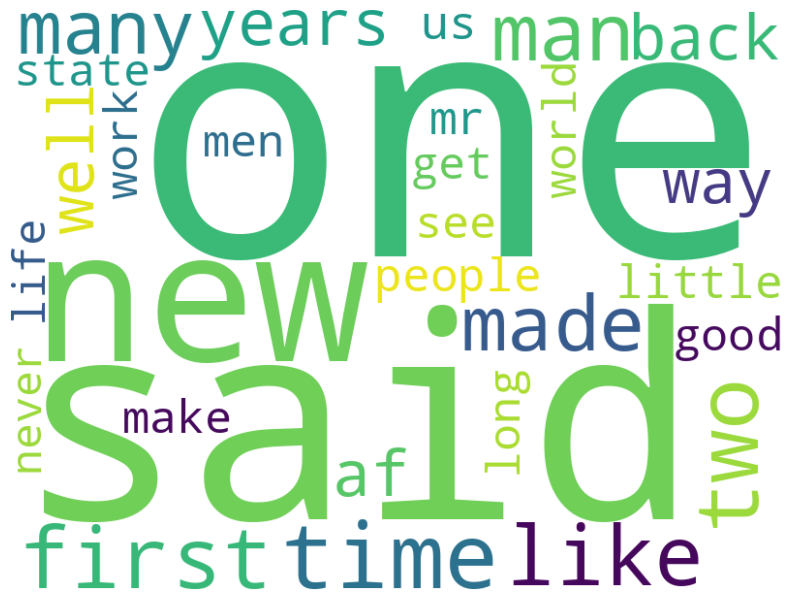

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

all_words = [token for sentence in cleaned_sentences for token in sentence]

# Count word frequencies
word_freq = Counter(all_words)

# Take top 20 words
top_words = dict(word_freq.most_common(30))

# Generate WordCloud
wc = WordCloud(width=800, height=600, background_color='white')
wc.generate_from_frequencies(top_words)

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  # hide axes
plt.show()

In [22]:
from sklearn.decomposition import PCA
import numpy as np

top_words = list(model.wv.index_to_key[:30])

vectors = np.array([model.wv[w] for w in top_words])
vectors_2d = PCA(n_components=2).fit_transform(vectors)
vectors_2d

array([[ 0.18949595, -0.17530833],
       [-0.9102481 , -0.5770884 ],
       [ 0.2488965 , -0.08386058],
       [-0.01359777, -0.16528775],
       [ 0.76910216,  1.722848  ],
       [-0.4486134 ,  0.3866577 ],
       [-0.17964722,  0.49225503],
       [ 0.1233395 , -2.1964028 ],
       [-3.74994   ,  2.3569574 ],
       [ 1.235259  ,  0.6839928 ],
       [ 0.7332385 ,  0.03495571],
       [ 2.3349218 ,  2.706593  ],
       [-0.14786176, -0.09799837],
       [ 0.14705068, -0.2225297 ],
       [ 0.02350672,  0.67748165],
       [ 0.8033783 , -0.7595655 ],
       [-1.855886  , -2.7386332 ],
       [ 0.897258  , -0.7394853 ],
       [-0.52199537, -0.9198292 ],
       [ 1.7080055 ,  0.9560744 ],
       [ 0.304328  ,  0.31031743],
       [-2.734195  ,  1.3996208 ],
       [ 0.8327441 , -0.61288863],
       [-1.1047184 ,  0.18947938],
       [ 0.87465674, -0.3354154 ],
       [ 0.3896057 , -0.0199374 ],
       [ 0.5369267 , -0.3070485 ],
       [-1.0804392 ,  0.06279921],
       [ 0.5645495 ,

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=vectors_2d[:, 0],
    y=vectors_2d[:, 1],
    mode='markers+text',
    text=top_words,
    textposition='top center'
))
fig.update_layout(title="Word2Vec Word Visualization (2D PCA)")
fig.show()


In [24]:
# Print the first 500 characters of the Plotly JSON
plotly_json = fig.to_json()
print(plotly_json[:500])

{"data":[{"mode":"markers+text","text":["one","said","new","time","two","first","like","man","made","many","years","af","back","well","way","people","mr","us","little","state","good","make","world","see","men","work","long","get","life","never"],"textposition":"top center","x":{"dtype":"f4","bdata":"OgtCPgUGab+53n4+LclevOHjRD+osOW+cfU3vmyZ\u002fD0E\u002f2\u002fA+ByeP4W1Oz9cbxVAE2kXvnSUFj4pkcA8M6pNP6yN7b+zsmU\u002ffaEFv+2f2j\u002fh0Js+Df0uwLguVT9qZ42\u002fgelfP2Z6xz4HdAk\u002f1UuKv1GGED+C+\u002fw
